# 김지수 공백 영향도 — VS Code용 관계형 Graph Autoencoder

이 노트북은 VS Code의 Jupyter 확장에서 바로 실행합니다.

1. 우측 상단 **커널 선택**에서 프로젝트의 Python 인터프리터를 선택합니다.
2. 첫 번째 설치 셀부터 순서대로 실행합니다.
3. 워크스페이스의 `outputs/final_handoff_graph/synthetic_data_nDCG수정.json`을 자동으로 읽습니다.
4. 결과는 JSON과 같은 폴더 아래 `rgae_results`에 저장합니다.

정상 그래프로 관계형 GAE를 한 번 학습한 뒤 김지수 연결만 제거한 counterfactual 그래프를 같은 모델로 복원하여 Task별 `Δ reconstruction error`를 계산합니다.


In [49]:
# VS Code에서 현재 선택한 Jupyter 커널에 설치됩니다.
%pip install -q torch torch-geometric pandas numpy matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
# @title 2. 기본 설정
import json
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import RGCNConv

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cpu


## 로컬 그래프 경로

VS Code가 워크스페이스 루트 또는 노트북 폴더 중 어디를 작업 디렉터리로 사용해도 JSON을 찾도록 후보 경로를 확인합니다.


In [51]:
# @title 3. 로컬 JSON 경로 설정
from pathlib import Path

candidate_paths = [
    Path.cwd() / 'outputs' / 'final_handoff_graph' / 'synthetic_data_nDCG수정.json',
    Path.cwd() / 'synthetic_data_nDCG수정.json',
    Path.cwd().parent / 'final_handoff_graph' / 'synthetic_data_nDCG수정.json',
]

GRAPH_PATH = next((path.resolve() for path in candidate_paths if path.exists()), None)
if GRAPH_PATH is None:
    checked = '\n'.join(str(path.resolve()) for path in candidate_paths)
    raise FileNotFoundError(f'그래프 JSON을 찾을 수 없습니다. 확인한 경로:\n{checked}')

OUTPUT_DIR = GRAPH_PATH.parent / 'rgae_results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('graph path:', GRAPH_PATH)
print('output dir:', OUTPUT_DIR)


graph path: C:\Users\zisin\Desktop\capstone\synthetic_data_nDCG수정.json
output dir: C:\Users\zisin\Desktop\capstone\rgae_results


In [52]:
# @title 4. 그래프 로드 및 인덱스 생성
with open(GRAPH_PATH, 'r', encoding='utf-8') as f:
    graph = json.load(f)

nodes = graph['nodes']
edges = graph['edges']

node_ids = [node['id'] for node in nodes]
node_to_idx = {node_id: idx for idx, node_id in enumerate(node_ids)}
idx_to_node = {idx: node for idx, node in enumerate(nodes)}

relation_names = sorted({edge['type'] for edge in edges})
relation_to_idx = {name: idx for idx, name in enumerate(relation_names)}

edge_index = torch.tensor([
    [node_to_idx[edge['from']] for edge in edges],
    [node_to_idx[edge['to']] for edge in edges],
], dtype=torch.long)
edge_type = torch.tensor(
    [relation_to_idx[edge['type']] for edge in edges],
    dtype=torch.long,
)

print('nodes:', len(nodes))
print('edges:', len(edges))
print('relations:', relation_names)
print(pd.Series([node['type'] for node in nodes]).value_counts())


nodes: 162
edges: 1000
relations: ['APPROVES', 'BACKUP_FOR', 'CONTAINS', 'CONTEXT_FOR', 'CONTRIBUTES_TO', 'COORDINATES', 'DEPENDS_ON', 'RESPONSIBLE_FOR', 'REVIEWS']
Task       100
Person      50
Project     12
Name: count, dtype: int64


In [53]:
# @title 5. 노드 특징 생성
# ID one-hot 대신 타입·업무 상태·고정 랜덤 특징을 사용합니다.
# 랜덤 특징은 두 그래프에서 동일하므로 공백 전후 차이는 구조 변화에서 발생합니다.
node_types = sorted({node['type'] for node in nodes})
node_type_to_idx = {name: idx for idx, name in enumerate(node_types)}

task_statuses = sorted({
    node.get('status', 'none')
    for node in nodes
    if node['type'] == 'Task'
})
status_to_idx = {name: idx for idx, name in enumerate(task_statuses)}

type_features = torch.zeros((len(nodes), len(node_types)))
status_features = torch.zeros((len(nodes), len(task_statuses)))

for idx, node in enumerate(nodes):
    type_features[idx, node_type_to_idx[node['type']]] = 1.0
    if node['type'] == 'Task':
        status_features[idx, status_to_idx[node.get('status', 'none')]] = 1.0

generator = torch.Generator().manual_seed(SEED)
random_features = torch.randn((len(nodes), 16), generator=generator) * 0.1
x = torch.cat([type_features, status_features, random_features], dim=1)

print('feature shape:', x.shape)
print('node types:', node_types)
print('task statuses:', task_statuses)


feature shape: torch.Size([162, 25])
node types: ['Person', 'Project', 'Task']
task statuses: ['completed', 'in_progress', 'pending_review', 'recurring', 'waiting_for_dependency', 'waiting_for_response']


In [54]:
# @title 6. 관계 타입과 목적지 노드 타입을 보존하는 negative sampling (진짜 edge vs negative edge)
known_triples = {
    (node_to_idx[edge['from']], node_to_idx[edge['to']], relation_to_idx[edge['type']])
    for edge in edges
}

node_type_by_idx = [node['type'] for node in nodes]
nodes_by_type = defaultdict(list)
for idx, node_type_name in enumerate(node_type_by_idx):
    nodes_by_type[node_type_name].append(idx)

def sample_negative_edges(pos_edge_index, pos_edge_type, seed=SEED):
    rng = random.Random(seed)
    neg_src, neg_dst, neg_rel = [], [], []

    for src, dst, rel in zip(
        pos_edge_index[0].tolist(),
        pos_edge_index[1].tolist(),
        pos_edge_type.tolist(),
    ):
        target_type = node_type_by_idx[dst]
        candidates = nodes_by_type[target_type]

        for _ in range(200):
            candidate = rng.choice(candidates)
            if candidate != dst and (src, candidate, rel) not in known_triples:
                neg_src.append(src)
                neg_dst.append(candidate)
                neg_rel.append(rel)
                break
        else:
            raise RuntimeError(f'negative edge sampling failed: {(src, dst, rel)}')

    return (
        torch.tensor([neg_src, neg_dst], dtype=torch.long),
        torch.tensor(neg_rel, dtype=torch.long),
    )

eval_neg_edge_index, eval_neg_edge_type = sample_negative_edges(
    edge_index,
    edge_type,
    seed=SEED + 1000,
)
print('negative evaluation edges:', eval_neg_edge_index.shape[1])


negative evaluation edges: 1000


In [55]:
# @title 7. Relational Graph Autoencoder 정의
class RelationalGraphAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_relations):
        super().__init__()
        num_bases = min(8, num_relations)
        self.conv1 = RGCNConv(
            input_dim,
            hidden_dim,
            num_relations=num_relations,
            num_bases=num_bases,
        )
        self.conv2 = RGCNConv(
            hidden_dim,
            latent_dim,
            num_relations=num_relations,
            num_bases=num_bases,
        )
        self.relation_embedding = nn.Embedding(num_relations, 16)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim * 2 + 16, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, 1),
        )

    def encode(self, node_features, graph_edge_index, graph_edge_type):
        z = self.conv1(node_features, graph_edge_index, graph_edge_type)
        z = F.relu(z)
        z = self.conv2(z, graph_edge_index, graph_edge_type)
        return z

    def decode(self, z, candidate_edge_index, candidate_edge_type):
        src = z[candidate_edge_index[0]]
        dst = z[candidate_edge_index[1]]
        rel = self.relation_embedding(candidate_edge_type)
        return self.decoder(torch.cat([src, dst, rel], dim=1)).squeeze(-1)

model = RelationalGraphAutoencoder(
    input_dim=x.shape[1],
    hidden_dim=64,
    latent_dim=32,
    num_relations=len(relation_names),
).to(device)

x_device = x.to(device)
edge_index_device = edge_index.to(device)
edge_type_device = edge_type.to(device)
print(model)


RelationalGraphAutoencoder(
  (conv1): RGCNConv(25, 64, num_relations=9)
  (conv2): RGCNConv(64, 32, num_relations=9)
  (relation_embedding): Embedding(9, 16)
  (decoder): Sequential(
    (0): Linear(in_features=80, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [56]:
# @title 8. 정상 그래프로 학습
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
epochs = 600

model.train()
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    z = model.encode(x_device, edge_index_device, edge_type_device)
    neg_edge_index, neg_edge_type = sample_negative_edges(
        edge_index,
        edge_type,
        seed=SEED + epoch,
    )
    neg_edge_index = neg_edge_index.to(device)
    neg_edge_type = neg_edge_type.to(device)

    pos_logits = model.decode(z, edge_index_device, edge_type_device)
    neg_logits = model.decode(z, neg_edge_index, neg_edge_type)

    logits = torch.cat([pos_logits, neg_logits])
    labels = torch.cat([
        torch.ones_like(pos_logits),
        torch.zeros_like(neg_logits),
    ])
    loss = F.binary_cross_entropy_with_logits(logits, labels)
    loss.backward()
    optimizer.step()

    if epoch == 1 or epoch % 100 == 0:
        print(f'epoch={epoch:03d}, loss={loss.item():.6f}')


epoch=001, loss=0.695378
epoch=100, loss=0.491206
epoch=200, loss=0.339732
epoch=300, loss=0.263299
epoch=400, loss=0.216727
epoch=500, loss=0.176473
epoch=600, loss=0.166584


In [57]:
# @title 9. 김지수 제거 counterfactual 그래프 생성
KIM_ID = 'person:EMP-009'
kim_idx = node_to_idx[KIM_ID]

# 김지수와 연결된 모든 엣지를 제거합니다.
counterfactual_mask = (
    (edge_index[0] != kim_idx) &
    (edge_index[1] != kim_idx)
)
edge_index_cf = edge_index[:, counterfactual_mask]
edge_type_cf = edge_type[counterfactual_mask]

# 동일한 노드 인덱스로 Task별 오차를 직접 비교하기 위한 빈 자리입니다.
x_cf = x.clone()
x_cf[kim_idx] = 0.0

print('normal edges:', edge_index.shape[1])
print('counterfactual edges:', edge_index_cf.shape[1])
print('removed incident edges:', int((~counterfactual_mask).sum()))


normal edges: 1000
counterfactual edges: 992
removed incident edges: 8


In [58]:
# @title 10. 정상·counterfactual reconstruction error 계산
model.eval()
with torch.no_grad():
    z_normal = model.encode(
        x.to(device),
        edge_index.to(device),
        edge_type.to(device),
    )
    z_cf = model.encode(
        x_cf.to(device),
        edge_index_cf.to(device),
        edge_type_cf.to(device),
    )
    # 인덱스 정렬용 빈 자리도 decoder에서는 완전히 제거된 상태로 취급합니다.
    z_cf[kim_idx] = 0.0

    eval_edge_index = torch.cat([edge_index, eval_neg_edge_index], dim=1).to(device)
    eval_edge_type = torch.cat([edge_type, eval_neg_edge_type]).to(device)
    eval_labels = torch.cat([
        torch.ones(edge_index.shape[1]),
        torch.zeros(eval_neg_edge_index.shape[1]),
    ]).to(device)

    normal_logits = model.decode(z_normal, eval_edge_index, eval_edge_type)
    cf_logits = model.decode(z_cf, eval_edge_index, eval_edge_type)

    normal_edge_error = F.binary_cross_entropy_with_logits(
        normal_logits,
        eval_labels,
        reduction='none',
    ).cpu()
    cf_edge_error = F.binary_cross_entropy_with_logits(
        cf_logits,
        eval_labels,
        reduction='none',
    ).cpu()

eval_edge_index_cpu = eval_edge_index.cpu()
task_indices = {
    idx for idx, node in enumerate(nodes)
    if node['type'] == 'Task'
}

normal_by_task = defaultdict(list)
cf_by_task = defaultdict(list)

for edge_pos in range(eval_edge_index_cpu.shape[1]):
    src = int(eval_edge_index_cpu[0, edge_pos])
    dst = int(eval_edge_index_cpu[1, edge_pos])
    for node_idx in {src, dst}:
        if node_idx in task_indices:
            normal_by_task[node_idx].append(float(normal_edge_error[edge_pos]))
            cf_by_task[node_idx].append(float(cf_edge_error[edge_pos]))

gt_by_task = {
    label['task_id']: label
    for label in graph.get('ground_truth', {}).get('labels', [])
}

rows = []
for task_idx in sorted(task_indices):
    node = idx_to_node[task_idx]
    normal_error = float(np.mean(normal_by_task[task_idx]))
    cf_error = float(np.mean(cf_by_task[task_idx]))
    gt = gt_by_task.get(node['id'], {})
    rows.append({
        'task_id': node['id'],
        'task_name': node['name'],
        'normal_error': normal_error,
        'counterfactual_error': cf_error,
        'delta_error': cf_error - normal_error,
        'gt_impact_label': gt.get('impact_label'),
        'gt_rank': gt.get('rank'),
        'gt_reason': gt.get('reason'),
    })

result_df = pd.DataFrame(rows).sort_values(
    ['delta_error', 'counterfactual_error'],
    ascending=False,
).reset_index(drop=True)
result_df['impact_rank'] = np.arange(1, len(result_df) + 1)

result_df.head(10)


,task_id,task_name,normal_error,counterfactual_error,delta_error,gt_impact_label,gt_rank,gt_reason,impact_rank
0,task:P08-T11,고객사 최종 회신 취합 및 변경 공지,0.005834,3.175365,3.169531,1,2.0,"김지수 협업 조정, 진행·대기 중이며 대체 담당자 없음, 선행 업무 2개 수렴, 교...",1
1,task:P08-T12,긴급 이슈 임시 운영안 검토,0.000768,2.037871,2.037103,1,5.0,"진행·대기 중이며 대체 담당자 없음, 교차 프로젝트 연결, 마감 당일·경과",2
2,task:P08-T5,주간 프로젝트 회의 운영,0.012451,1.806075,1.793624,1,7.0,"김지수 협업 조정, 대체 담당자 감점",3
3,task:P08-T10,고객사 변경사항 긴급 메일 회신,0.003718,1.605680,1.601962,1,1.0,"김지수 책임 담당, 김지수 단독 담당·대체자 없음·업무 의존 엣지 없음, 마감 당일·경과",4
4,task:P03-T7,QA 결과 수렴 및 배포 준비,0.145169,1.733135,1.587966,1,3.0,"김지수 협업 조정, 선행 업무 2개 수렴, 교차 프로젝트 연결, 마감 당일·경과, ...",5
5,task:P12-T7,국가별 검토 수렴 및 출시 준비,0.036787,0.337755,0.300968,0,NaN,김지수 직접 관계 없음 — GT 제외,6
6,task:P04-T5,이미지·카피 시안 검토,0.121904,0.269064,0.147160,0,NaN,김지수 직접 관계 없음 — GT 제외,7
7,task:P04-T3,캠페인 운영안 기획,0.142134,0.272820,0.130686,0,NaN,김지수 직접 관계 없음 — GT 제외,8
8,task:P01-T6,개발 가능 범위 협의,0.200579,0.266232,0.065654,1,4.0,"김지수 협업 참여, 선행 업무 2개 수렴, 마감 당일·경과, 대체 담당자 감점",9
9,task:P07-T8,주간 혜택 운영 점검,0.115941,0.146136,0.030195,1,8.0,"김지수 협업 참여, 대체 담당자 감점",10


In [65]:
# @title 11. Precision@K / Recall@K
def precision_recall_at_k(df, k):
    valid = df.dropna(subset=['gt_impact_label']).copy()
    positives = int((valid['gt_impact_label'] == 1).sum())
    top_k = valid.nlargest(k, 'delta_error')
    true_positive = int((top_k['gt_impact_label'] == 1).sum())
    precision = true_positive / k if k else 0.0
    recall = true_positive / positives if positives else 0.0
    return {
        'K': k,
        'TP': true_positive,
        'GT positives': positives,
        'Precision@K': precision,
        'Recall@K': recall,
    }

metric_df = pd.DataFrame([
    precision_recall_at_k(result_df, k)
    for k in [5, 10]
])
metric_df


,K,TP,GT positives,Precision@K,Recall@K
0,5,5,8,1.0,0.625
1,10,7,8,0.7,0.875


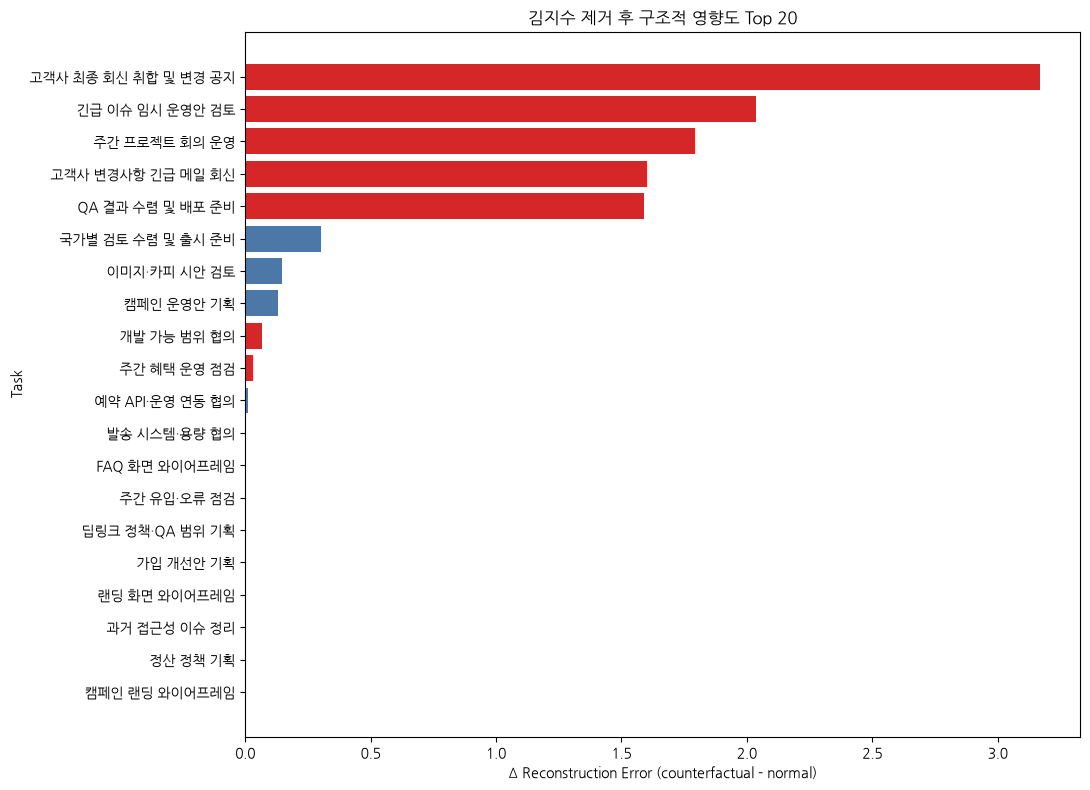

저장 완료
 - C:\Users\zisin\Desktop\capstone\rgae_results\kim_jisoo_task_impact_ranking.csv
 - C:\Users\zisin\Desktop\capstone\rgae_results\kim_jisoo_precision_recall_at_k.csv
 - C:\Users\zisin\Desktop\capstone\rgae_results\kim_jisoo_task_impact_top20.png
 - C:\Users\zisin\Desktop\capstone\rgae_results\relational_gae_model.pt


In [66]:
# @title 12. 영향도 시각화 및 로컬 파일 저장
plt.rcParams['font.family'] = 'NanumGothic'
top_n = 20
plot_df = result_df.head(top_n).sort_values('delta_error')

plt.figure(figsize=(11, 8))
colors = [
    '#d62728' if label == 1 else '#4c78a8'
    for label in plot_df['gt_impact_label']
]
plt.barh(plot_df['task_name'], plot_df['delta_error'], color=colors)
plt.xlabel('Δ Reconstruction Error (counterfactual - normal)')
plt.ylabel('Task')
plt.title('김지수 제거 후 구조적 영향도 Top 20')
plt.tight_layout()

RESULT_PATH = OUTPUT_DIR / 'kim_jisoo_task_impact_ranking.csv'
METRIC_PATH = OUTPUT_DIR / 'kim_jisoo_precision_recall_at_k.csv'
PLOT_PATH = OUTPUT_DIR / 'kim_jisoo_task_impact_top20.png'
MODEL_PATH = OUTPUT_DIR / 'relational_gae_model.pt'

plt.savefig(PLOT_PATH, dpi=180, bbox_inches='tight')
plt.show()

result_df.to_csv(RESULT_PATH, index=False, encoding='utf-8-sig')
metric_df.to_csv(METRIC_PATH, index=False, encoding='utf-8-sig')
torch.save({
    'model_state_dict': model.state_dict(),
    'node_to_idx': node_to_idx,
    'relation_names': relation_names,
    'feature_dim': x.shape[1],
}, MODEL_PATH)

print('저장 완료')
for saved_path in [RESULT_PATH, METRIC_PATH, PLOT_PATH, MODEL_PATH]:
    print(' -', saved_path.resolve())


In [67]:
# @title 13. 영향도 상위 결과 확인
display(result_df.head(20))
display(metric_df)


,task_id,task_name,normal_error,counterfactual_error,delta_error,gt_impact_label,gt_rank,gt_reason,impact_rank
0,task:P08-T11,고객사 최종 회신 취합 및 변경 공지,0.005834,3.175365,3.169531,1,2.0,"김지수 협업 조정, 진행·대기 중이며 대체 담당자 없음, 선행 업무 2개 수렴, 교...",1
1,task:P08-T12,긴급 이슈 임시 운영안 검토,0.000768,2.037871,2.037103,1,5.0,"진행·대기 중이며 대체 담당자 없음, 교차 프로젝트 연결, 마감 당일·경과",2
2,task:P08-T5,주간 프로젝트 회의 운영,0.012451,1.806075,1.793624,1,7.0,"김지수 협업 조정, 대체 담당자 감점",3
3,task:P08-T10,고객사 변경사항 긴급 메일 회신,0.003718,1.605680,1.601962,1,1.0,"김지수 책임 담당, 김지수 단독 담당·대체자 없음·업무 의존 엣지 없음, 마감 당일·경과",4
4,task:P03-T7,QA 결과 수렴 및 배포 준비,0.145169,1.733135,1.587966,1,3.0,"김지수 협업 조정, 선행 업무 2개 수렴, 교차 프로젝트 연결, 마감 당일·경과, ...",5
5,task:P12-T7,국가별 검토 수렴 및 출시 준비,0.036787,0.337755,0.300968,0,NaN,김지수 직접 관계 없음 — GT 제외,6
6,task:P04-T5,이미지·카피 시안 검토,0.121904,0.269064,0.147160,0,NaN,김지수 직접 관계 없음 — GT 제외,7
7,task:P04-T3,캠페인 운영안 기획,0.142134,0.272820,0.130686,0,NaN,김지수 직접 관계 없음 — GT 제외,8
8,task:P01-T6,개발 가능 범위 협의,0.200579,0.266232,0.065654,1,4.0,"김지수 협업 참여, 선행 업무 2개 수렴, 마감 당일·경과, 대체 담당자 감점",9
9,task:P07-T8,주간 혜택 운영 점검,0.115941,0.146136,0.030195,1,8.0,"김지수 협업 참여, 대체 담당자 감점",10


,K,TP,GT positives,Precision@K,Recall@K
0,5,5,8,1.0,0.625
1,10,7,8,0.7,0.875


## 해석 기준

- `normal_error`: 정상 그래프를 복원할 때 해당 Task 주변 엣지의 평균 오차
- `counterfactual_error`: 김지수 연결을 제거한 그래프를 같은 모델로 복원할 때의 평균 오차
- `delta_error`: 공백 이후 증가한 오차. 클수록 김지수 제거로 구조가 비정상적으로 변한 Task
- 빨간색 막대: 사전 정의한 Ground Truth 영향 Task

모델은 정상 그래프에서만 학습합니다. Counterfactual 그래프를 별도로 재학습하면 공백 구조에 모델이 적응하므로 이상 영향도가 약해질 수 있습니다.


## Baseline 비교 설계
김지수와 직접 연결된 9개 Task만 후보로 두면 모든 후보가 GT 양성이어서 비교 지표가 무의미해집니다. 따라서 김지수 2-hop ego subgraph 안의 모든 Task를 공통 후보로 두고, 그중 김지수와 직접 업무 관계가 있는 9개 Task를 GT 양성으로 평가합니다.
- Degree: Task에 연결된 고유 Person 수
- Betweenness: 같은 2-hop subgraph 안의 Task 매개 중심성
- R-GAE: 같은 후보 Task의 Δ reconstruction error
- 평가 지표: Precision@K, Recall@K

In [72]:
# @title 14. 김지수 2-hop 평가 subgraph 및 GT 구성
import networkx as nx

EGO_HOPS = 2
K_VALUES = [3, 5, 10]
KIM_ID = graph.get('ground_truth', {}).get('absence_subject_id', 'person:EMP-009')
node_by_id = {node['id']: node for node in nodes}

full_nx = nx.Graph()
for node in nodes:
    full_nx.add_node(node['id'], node_type=node.get('type'), name=node.get('name'))
for edge in edges:
    full_nx.add_edge(edge['from'], edge['to'])

if KIM_ID not in full_nx:
    raise KeyError(f'김지수 노드가 없습니다: {KIM_ID}')

ego_nx = nx.ego_graph(full_nx, KIM_ID, radius=EGO_HOPS, undirected=True)
candidate_task_ids = sorted(
    node_id for node_id in ego_nx.nodes
    if node_by_id[node_id].get('type') == 'Task'
)
gt_score_by_task = {
    label['task_id']: float(label.get('score', 0))
    for label in graph.get('ground_truth', {}).get('labels', [])
}
ranked_gt_labels = [
    label for label in graph.get('ground_truth', {}).get('labels', [])
    if label.get('rank') is not None
]
max_gt_rank = max((int(label['rank']) for label in ranked_gt_labels), default=0)
gt_rank_by_task = {
    label['task_id']: int(label['rank']) for label in ranked_gt_labels
}
# nDCG용 graded relevance: GT 1위=N, 2위=N-1, ..., N위=1, 비관련=0
gt_relevance_by_task = {
    task_id: float(max_gt_rank - rank + 1)
    for task_id, rank in gt_rank_by_task.items()
}
gt_positive_in_candidates = {
    task_id for task_id in candidate_task_ids
    if gt_score_by_task.get(task_id, 0) > 0
}

if not gt_positive_in_candidates:
    raise ValueError('평가 후보군 안에 GT 양성 Task가 없습니다.')

print('ego hops:', EGO_HOPS)
print('ego nodes / edges:', ego_nx.number_of_nodes(), '/', ego_nx.number_of_edges())
print('candidate tasks:', len(candidate_task_ids))
print('GT positive relevance tasks:', len(gt_positive_in_candidates))
print('GT task IDs:', sorted(gt_positive_in_candidates))
print('GT rank relevance:', gt_relevance_by_task)
print('중요: 김지수 제거는 위 R-GAE 계산에만 사용하며 baseline 그래프는 full_nx/ego_nx 원본입니다.')


ego hops: 2
ego nodes / edges: 50 / 156
candidate tasks: 23
GT positive relevance tasks: 8
GT task IDs: ['task:P01-T6', 'task:P03-T7', 'task:P07-T8', 'task:P08-T10', 'task:P08-T11', 'task:P08-T12', 'task:P08-T5', 'task:P11-T2']
GT rank relevance: {'task:P01-T6': 5.0, 'task:P03-T7': 6.0, 'task:P07-T8': 1.0, 'task:P08-T5': 2.0, 'task:P11-T2': 3.0, 'task:P08-T10': 8.0, 'task:P08-T11': 7.0, 'task:P08-T12': 4.0}
중요: 김지수 제거는 위 R-GAE 계산에만 사용하며 baseline 그래프는 full_nx/ego_nx 원본입니다.


In [69]:
# @title 15. Degree·Betweenness·R-GAE 점수와 순위
PERSON_TASK_RELATIONS = {
    'RESPONSIBLE_FOR', 'CONTRIBUTES_TO', 'REVIEWS',
    'APPROVES', 'COORDINATES', 'BACKUP_FOR',
}

person_neighbors_by_task = {task_id: set() for task_id in candidate_task_ids}
for edge in edges:
    if edge.get('type') not in PERSON_TASK_RELATIONS:
        continue
    src, dst = edge['from'], edge['to']
    src_type = node_by_id.get(src, {}).get('type')
    dst_type = node_by_id.get(dst, {}).get('type')
    if src_type == 'Person' and dst in person_neighbors_by_task:
        person_neighbors_by_task[dst].add(src)
    elif dst_type == 'Person' and src in person_neighbors_by_task:
        person_neighbors_by_task[src].add(dst)

betweenness = nx.betweenness_centrality(ego_nx, normalized=True, weight=None)
gae_score_by_task = result_df.set_index('task_id')['delta_error'].to_dict()

baseline_df = pd.DataFrame([{
    'task_id': task_id,
    'task_name': node_by_id[task_id].get('name'),
        'gt_score': float(gt_score_by_task.get(task_id, 0)),
        'gt_rank': gt_rank_by_task.get(task_id),
        'gt_relevance': float(gt_relevance_by_task.get(task_id, 0)),
        'gt_impact_label': int(gt_score_by_task.get(task_id, 0) > 0),
    'person_degree': len(person_neighbors_by_task[task_id]),
    'total_degree_in_ego': int(ego_nx.degree(task_id)),
    'betweenness': float(betweenness.get(task_id, 0.0)),
    'rgae_delta_error': float(gae_score_by_task.get(task_id, np.nan)),
} for task_id in candidate_task_ids])

if baseline_df['rgae_delta_error'].isna().any():
    missing = baseline_df.loc[baseline_df['rgae_delta_error'].isna(), 'task_id'].tolist()
    raise ValueError(f'R-GAE 결과가 없는 후보 Task: {missing}')

degree_ranking = baseline_df.sort_values(
    ['person_degree', 'total_degree_in_ego', 'task_id'],
    ascending=[False, False, True],
).reset_index(drop=True)
degree_ranking['degree_rank'] = np.arange(1, len(degree_ranking) + 1)

betweenness_ranking = baseline_df.sort_values(
    ['betweenness', 'person_degree', 'task_id'],
    ascending=[False, False, True],
).reset_index(drop=True)
betweenness_ranking['betweenness_rank'] = np.arange(1, len(betweenness_ranking) + 1)

rgae_ranking = baseline_df.sort_values(
    ['rgae_delta_error', 'betweenness', 'task_id'],
    ascending=[False, False, True],
).reset_index(drop=True)
rgae_ranking['rgae_rank'] = np.arange(1, len(rgae_ranking) + 1)

display(degree_ranking.head(10))
display(betweenness_ranking.head(10))
display(rgae_ranking.head(10))


,task_id,task_name,gt_score,gt_rank,gt_relevance,gt_impact_label,person_degree,total_degree_in_ego,betweenness,rgae_delta_error,degree_rank
0,task:P01-T6,개발 가능 범위 협의,87.0,4.0,5.0,1,8,12,0.082609,0.065654,1
1,task:P11-T2,접근성 이용 데이터 분석,40.0,6.0,3.0,1,8,11,0.062914,-0.023774,2
2,task:P07-T8,주간 혜택 운영 점검,37.0,8.0,1.0,1,8,10,0.080812,0.030195,3
3,task:P11-T3,접근성 개선안 기획,0.0,NaN,0.0,0,8,10,0.041452,0.000026,4
4,task:P08-T7,월간 수렴 회의 준비,0.0,NaN,0.0,0,8,9,0.055383,-0.000016,5
5,task:P01-T4,가입 화면 와이어프레임,0.0,NaN,0.0,0,8,8,0.033785,-0.000457,6
6,task:P08-T4,주간 회의실 예약,0.0,NaN,0.0,0,8,8,0.041001,-0.012969,7
7,task:P04-T6,발송 시스템·용량 협의,0.0,NaN,0.0,0,8,7,0.014556,0.002006,8
8,task:P07-T7,통합 검토 및 시행 준비,0.0,NaN,0.0,0,8,7,0.028887,-0.002968,9
9,task:P03-T6,AOS·iOS 개발 협의,0.0,NaN,0.0,0,8,5,0.005988,-0.002588,10


,task_id,task_name,gt_score,gt_rank,gt_relevance,gt_impact_label,person_degree,total_degree_in_ego,betweenness,rgae_delta_error,betweenness_rank
0,task:P03-T7,QA 결과 수렴 및 배포 준비,110.0,3.0,6.0,1,7,15,0.129964,1.587966,1
1,task:P08-T5,주간 프로젝트 회의 운영,39.0,7.0,2.0,1,7,10,0.124373,1.793624,2
2,task:P01-T6,개발 가능 범위 협의,87.0,4.0,5.0,1,8,12,0.082609,0.065654,3
3,task:P07-T8,주간 혜택 운영 점검,37.0,8.0,1.0,1,8,10,0.080812,0.030195,4
4,task:P11-T2,접근성 이용 데이터 분석,40.0,6.0,3.0,1,8,11,0.062914,-0.023774,5
5,task:P08-T7,월간 수렴 회의 준비,0.0,NaN,0.0,0,8,9,0.055383,-0.000016,6
6,task:P11-T3,접근성 개선안 기획,0.0,NaN,0.0,0,8,10,0.041452,0.000026,7
7,task:P08-T4,주간 회의실 예약,0.0,NaN,0.0,0,8,8,0.041001,-0.012969,8
8,task:P01-T7,통합 검토 및 출시 준비,0.0,NaN,0.0,0,7,8,0.037349,-0.005253,9
9,task:P01-T4,가입 화면 와이어프레임,0.0,NaN,0.0,0,8,8,0.033785,-0.000457,10


,task_id,task_name,gt_score,gt_rank,gt_relevance,gt_impact_label,person_degree,total_degree_in_ego,betweenness,rgae_delta_error,rgae_rank
0,task:P08-T11,고객사 최종 회신 취합 및 변경 공지,113.0,2.0,7.0,1,3,6,0.011767,3.169531,1
1,task:P08-T12,긴급 이슈 임시 운영안 검토,80.0,5.0,4.0,1,2,4,0.004757,2.037103,2
2,task:P08-T5,주간 프로젝트 회의 운영,39.0,7.0,2.0,1,7,10,0.124373,1.793624,3
3,task:P08-T10,고객사 변경사항 긴급 메일 회신,135.0,1.0,8.0,1,1,2,0.000762,1.601962,4
4,task:P03-T7,QA 결과 수렴 및 배포 준비,110.0,3.0,6.0,1,7,15,0.129964,1.587966,5
5,task:P12-T7,국가별 검토 수렴 및 출시 준비,0.0,NaN,0.0,0,5,6,0.014713,0.300968,6
6,task:P04-T5,이미지·카피 시안 검토,0.0,NaN,0.0,0,7,5,0.019368,0.147160,7
7,task:P04-T3,캠페인 운영안 기획,0.0,NaN,0.0,0,5,7,0.021140,0.130686,8
8,task:P01-T6,개발 가능 범위 협의,87.0,4.0,5.0,1,8,12,0.082609,0.065654,9
9,task:P07-T8,주간 혜택 운영 점검,37.0,8.0,1.0,1,8,10,0.080812,0.030195,10


,method,requested_K,effective_K,candidate_tasks,nDCG@K,top_k_task_ids
0,R-GAE,3,3,23,0.376305,"task:P08-T11, task:P08-T12, task:P08-T5"
1,R-GAE,5,5,23,0.705472,"task:P08-T11, task:P08-T12, task:P08-T5, task:..."
2,R-GAE,10,10,23,0.723270,"task:P08-T11, task:P08-T12, task:P08-T5, task:..."
3,Degree,3,3,23,0.097964,"task:P01-T6, task:P11-T2, task:P07-T8"
4,Degree,5,5,23,0.093101,"task:P01-T6, task:P11-T2, task:P07-T8, task:P1..."
5,Degree,10,10,23,0.092190,"task:P01-T6, task:P11-T2, task:P07-T8, task:P1..."
6,Betweenness,3,3,23,0.219276,"task:P03-T7, task:P08-T5, task:P01-T6"
7,Betweenness,5,5,23,0.216525,"task:P03-T7, task:P08-T5, task:P01-T6, task:P0..."
8,Betweenness,10,10,23,0.214408,"task:P03-T7, task:P08-T5, task:P01-T6, task:P0..."


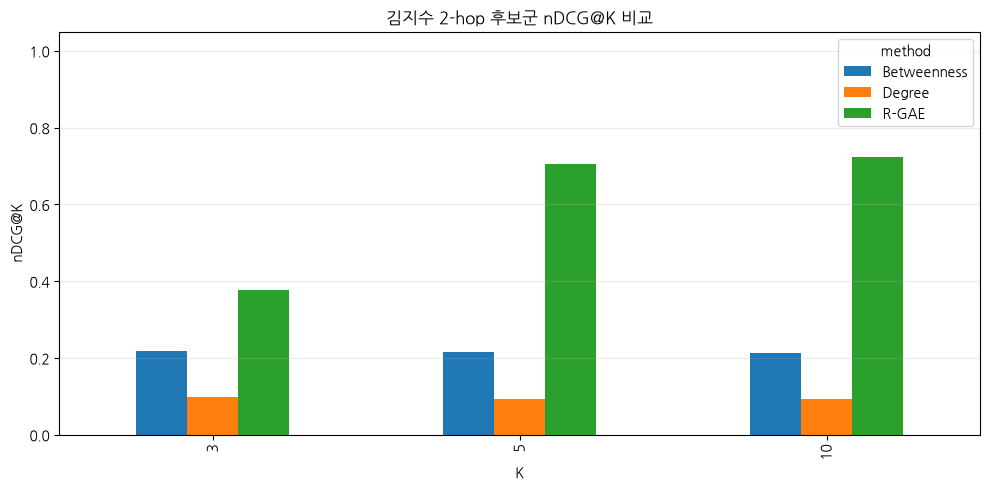

In [73]:
# @title 16. GT rank 기반 nDCG@K 비교
def dcg_at_k(relevances, k):
    values = np.asarray(relevances[:k], dtype=float)
    if values.size == 0:
        return 0.0
    discounts = np.log2(np.arange(2, values.size + 2))
    return float(np.sum((np.power(2.0, values) - 1.0) / discounts))

def ndcg_at_k(ranked_ids, relevance_by_task, requested_k):
    effective_k = min(requested_k, len(ranked_ids))
    predicted_relevance = [relevance_by_task.get(task_id, 0.0) for task_id in ranked_ids]
    ideal_relevance = sorted(
        [relevance_by_task.get(task_id, 0.0) for task_id in ranked_ids],
        reverse=True,
    )
    dcg = dcg_at_k(predicted_relevance, effective_k)
    idcg = dcg_at_k(ideal_relevance, effective_k)
    return dcg / idcg if idcg > 0 else 0.0

ranked_ids_by_method = {
    'R-GAE': rgae_ranking['task_id'].tolist(),
    'Degree': degree_ranking['task_id'].tolist(),
    'Betweenness': betweenness_ranking['task_id'].tolist(),
}
comparison_metric_df = pd.DataFrame([{
    'method': method,
    'requested_K': k,
    'effective_K': min(k, len(ranked_ids)),
    'candidate_tasks': len(ranked_ids),
    'nDCG@K': ndcg_at_k(ranked_ids, gt_relevance_by_task, k),
    'top_k_task_ids': ', '.join(ranked_ids[:min(k, len(ranked_ids))]),
} for method, ranked_ids in ranked_ids_by_method.items() for k in K_VALUES])
display(comparison_metric_df)

ax = comparison_metric_df.pivot(
    index='requested_K', columns='method', values='nDCG@K'
).plot(kind='bar', figsize=(10, 5), ylim=(0, 1.05))
ax.set_title(f'김지수 {EGO_HOPS}-hop 후보군 nDCG@K 비교')
ax.set_xlabel('K')
ax.set_ylabel('nDCG@K')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


In [ ]:
# @title 17. 비교 결과 저장
rank_table = baseline_df.copy()
rank_table = rank_table.merge(
    degree_ranking[['task_id', 'degree_rank']], on='task_id', how='left'
).merge(
    betweenness_ranking[['task_id', 'betweenness_rank']], on='task_id', how='left'
).merge(
    rgae_ranking[['task_id', 'rgae_rank']], on='task_id', how='left'
).sort_values('rgae_rank').reset_index(drop=True)

BASELINE_RANK_PATH = OUTPUT_DIR / 'kim_jisoo_baseline_rankings.csv'
BASELINE_METRIC_PATH = OUTPUT_DIR / 'kim_jisoo_baseline_ndcg_at_k.csv'
rank_table.to_csv(BASELINE_RANK_PATH, index=False, encoding='utf-8-sig')
comparison_metric_df.to_csv(BASELINE_METRIC_PATH, index=False, encoding='utf-8-sig')

print('저장 완료')
print(' -', BASELINE_RANK_PATH.resolve())
print(' -', BASELINE_METRIC_PATH.resolve())
display(rank_table.head(20)) 


저장 완료
 - C:\Users\zisin\Desktop\capstone\rgae_results\kim_jisoo_baseline_rankings.csv
 - C:\Users\zisin\Desktop\capstone\rgae_results\kim_jisoo_baseline_ndcg_at_k.csv


,task_id,task_name,gt_score,gt_rank,gt_relevance,gt_impact_label,person_degree,total_degree_in_ego,betweenness,rgae_delta_error,degree_rank,betweenness_rank,rgae_rank
0,task:P08-T11,고객사 최종 회신 취합 및 변경 공지,113.0,2.0,7.0,1,3,6,0.011767,3.169531,21,20,1
1,task:P08-T12,긴급 이슈 임시 운영안 검토,80.0,5.0,4.0,1,2,4,0.004757,2.037103,22,22,2
2,task:P08-T5,주간 프로젝트 회의 운영,39.0,7.0,2.0,1,7,10,0.124373,1.793624,12,2,3
3,task:P08-T10,고객사 변경사항 긴급 메일 회신,135.0,1.0,8.0,1,1,2,0.000762,1.601962,23,23,4
4,task:P03-T7,QA 결과 수렴 및 배포 준비,110.0,3.0,6.0,1,7,15,0.129964,1.587966,11,1,5
5,task:P12-T7,국가별 검토 수렴 및 출시 준비,0.0,NaN,0.0,0,5,6,0.014713,0.300968,20,18,6
6,task:P04-T5,이미지·카피 시안 검토,0.0,NaN,0.0,0,7,5,0.019368,0.147160,17,14,7
7,task:P04-T3,캠페인 운영안 기획,0.0,NaN,0.0,0,5,7,0.021140,0.130686,19,13,8
8,task:P01-T6,개발 가능 범위 협의,87.0,4.0,5.0,1,8,12,0.082609,0.065654,1,3,9
9,task:P07-T8,주간 혜택 운영 점검,37.0,8.0,1.0,1,8,10,0.080812,0.030195,3,4,10
